In [29]:
import pandas as pd


from dynamicTasteDistortion.scripts.vis import plot_metric_comparison
from dynamicTasteDistortion.simulationConstants import (
    RESULTS_PATH,
    SIMULATION_PATH,
    GLOBO_PATH,
)
from dynamicTasteDistortion.ioUtils import (
    load_pickle_artifact,
    read_experiment,
    get_cv_results_path,
)


from dynamicTasteDistortion.dataset_loader import read_globo_dataset_raw

## Utils functions and setups

In [ ]:
bpr_calibrated = "experiments/globo/bpr_calibrated.yaml"
bpr_uncalibrated = "experiments/globo/bpr_uncalibrated.yaml"
random_rec = "experiments/globo/random_uncalibrated.yaml"

In [ ]:
file_size = "1m"
num_users = 1000
data_type = "globo"

In [ ]:
def get_core_recsys_statistics(dataset):
    num_users = dataset["user"].nunique()
    num_items = dataset["item"].nunique()
    unique_genres = set(g for genres in dataset["genres"] for g in genres)
    num_genres = len(unique_genres)

    possible_interactions = num_users * num_items
    observed_interactions = len(dataset)
    sparsity = (
        1 - (observed_interactions / possible_interactions)
        if possible_interactions > 0
        else None
    )

    return {
        "num_users": num_users,
        "num_items": num_items,
        "num_genres": num_genres,
        "sparsity": sparsity,
    }

## Base dataset statistics

In [16]:
output_file_size = "1m"

In [18]:
globo_path = f"{GLOBO_PATH}/globo_{output_file_size}.pkl"

In [26]:
globo_df = load_pickle_artifact(globo_path)

In [22]:
globo_df["genres"].apply(len).max()

1

In [23]:
globo_df["genres"] = globo_df["genres"].apply(lambda g: g[0])

In [34]:
raw_globo_df_interactions = read_globo_dataset_raw()

Skipping: 'dynamicTasteDistortion/data/globo' already exists and contains files.
Download finished! Merging intermediate files.


Processing files...: 100%|██████████| 385/385 [00:38<00:00,  9.93it/s]


In [48]:
globo_articles = pd.read_csv(f"{GLOBO_PATH}/articles_metadata.csv")[
    ["article_id", "category_id"]
]
# # 50% percentile
# globo_articles = globo_articles[
#     globo_articles.groupby("category_id")["category_id"].transform("size") > 36
# ]
raw_globo_df = raw_globo_df_interactions.merge(globo_articles, on="article_id")

In [49]:
raw_globo_df = raw_globo_df.rename(
    columns={"user_id": "user", "article_id": "item", "category_id": "genres"}
)


In [50]:
raw_globo_df["genres"] = raw_globo_df["genres"].apply(lambda num: [num])

In [51]:
get_core_recsys_statistics(raw_globo_df)

{'num_users': 322897,
 'num_items': 46033,
 'num_genres': 316,
 'sparsity': 0.9997989641035282}

In [27]:
globo_df

,user,item,timestamp,rating,genres
0,51995,303565,1507549146755,1,[429]
1,117728,182394,1507012615290,1,[301]
2,38040,157078,1507071263126,1,[281]
3,191672,338339,1507411140350,1,[437]
4,61937,277107,1508172390550,1,[409]
...,...,...,...,...,...
1314587,2393,263830,1507292788409,0,[398]
1314588,2393,72327,1507292788409,0,[137]
1314589,45251,293205,1507034770373,0,[421]
1314590,45251,28539,1507034770373,0,[26]


In [28]:
get_core_recsys_statistics(globo_df)

{'num_users': 17749,
 'num_items': 14853,
 'num_genres': 130,
 'sparsity': 0.9950134185792832}

## Bootstrapped df - Statistics

In [5]:
bootstrapped_clicks_path = (
    f"{SIMULATION_PATH}/{data_type}_{file_size}_n_users={num_users}_bootstrapped.pkl"
)
bootstrapped_set = load_pickle_artifact(bootstrapped_clicks_path)

## Hyperparameters results

In [10]:
bootstrapped_set.columns

Index(['user', 'item', 'relevant', 'clicked_at', 'timestamp', 'rating',
       'constant', 'linear_time', 'genres'],
      dtype='object')

In [9]:
get_core_recsys_statistics(bootstrapped_set)

{'num_users': 1000,
 'num_items': 2944,
 'num_genres': 123,
 'sparsity': 0.8301606657608696,
 'positive_ratio': None}

In [7]:
bootstrapped_set.user.nunique(), bootstrapped_set.item.nunique(), bootstrapped_set.genres.nunique()

(1000, 2944, 123)

### Oracle



In [1]:
data_type = "globo"
size = "1m"

In [ ]:
destination_dir = f"{RESULTS_PATH}/{data_type}_{size}"
f1_results = load_pickle_artifact(f"{destination_dir}/oracle_model_f1_results.pkl")

In [10]:
import pandas as pd

In [ ]:
pd.set_option("display.max_rows", None)
f1_results[f1_results["is_winning_variant"]].sort_values(
    by="validation_f1", ascending=False
)

,model_name,params,validation_f1,test_f1,is_winning_variant
51,SVD++,"{'n_factors': 15, 'n_epochs': 10, 'lr_all': 0....",0.658021,0.0,True
22,SVD,"{'n_factors': 15, 'n_epochs': 10, 'lr_all': 0....",0.657771,0.0,True
76,NMF,"{'n_factors': 15, 'n_epochs': 100, 'reg_pu': 0...",0.634086,0.0,True


In [12]:
df = f1_results[f1_results["is_winning_variant"]]

In [15]:
df.sort_values(by="validation_f1", ascending=False)

,model_name,params,validation_f1,test_f1,is_winning_variant
51,SVD++,"{'n_factors': 15, 'n_epochs': 10, 'lr_all': 0....",0.658021,0.0,True
22,SVD,"{'n_factors': 15, 'n_epochs': 10, 'lr_all': 0....",0.657771,0.0,True
76,NMF,"{'n_factors': 15, 'n_epochs': 100, 'reg_pu': 0...",0.634086,0.0,True


In [ ]:
import ast

# If the dict column is stored as a string, convert it first
df["params"] = df["params"].apply(ast.literal_eval)

# Print full dataframe without truncation
with pd.option_context(
    "display.max_columns", None, "display.width", None, "display.max_colwidth", None
):
    print(df)

# Print each dict expanded
for idx, row in df.iterrows():
    print(f"\nRow {idx}:")
    print(row.drop("params").to_string())
    print("params:")
    for k, v in row["params"].items():
        print(f"  {k}: {v}")

   model_name  \
22        SVD   
51      SVD++   
76        NMF   

                                                                params  \
22  {'n_factors': 15, 'n_epochs': 10, 'lr_all': 0.01, 'reg_all': 0.02}   
51  {'n_factors': 15, 'n_epochs': 10, 'lr_all': 0.01, 'reg_all': 0.02}   
76  {'n_factors': 15, 'n_epochs': 100, 'reg_pu': 0.05, 'reg_qi': 0.02}   

    validation_f1  test_f1  is_winning_variant  
22       0.657771      0.0                True  
51       0.658021      0.0                True  
76       0.634086      0.0                True  

Row 22:
model_name                 SVD
validation_f1         0.657771
test_f1                    0.0
is_winning_variant        True
params:
  n_factors: 15
  n_epochs: 10
  lr_all: 0.01
  reg_all: 0.02

Row 51:
model_name               SVD++
validation_f1         0.658021
test_f1                    0.0
is_winning_variant        True
params:
  n_factors: 15
  n_epochs: 10
  lr_all: 0.01
  reg_all: 0.02

Row 76:
model_name             

### BPR

In [18]:
config = read_experiment(bpr_calibrated)

In [21]:
config

{'size': 's',
 'data': 'globo',
 'rounds': 2500,
 'num_rounds_per_eval': 250,
 'num_users': 1000,
 'model': 'bpr',
 'preference_update_rate': 0.1,
 'use_oracle_matrix': 'y',
 'calibrate': 'constant',
 'exp_name': 'bpr_unbiased_calibrated',
 'n_trials': 10,
 'params': {'factors': 64,
  'lr': 0.0001,
  'reg_lambda': 0.001,
  'num_negatives': 5,
  'n_epochs': 7}}

In [ ]:
config["data_type"] = config["data"]
config["file_size"] = file_size
config["model_type"] = config["model"]

In [52]:
cv_results_save_path = get_cv_results_path(config)
pd.read_csv(cv_results_save_path)

,Unnamed: 0,factors,lr,reg_lambda,num_negatives,n_epochs,map
0,5,64,0.00010,0.00100,5,7,0.133950
1,0,64,0.01000,0.00001,5,5,0.133203
2,18,32,0.01000,0.00001,5,10,0.133073
3,9,64,0.01000,0.01000,5,7,0.132870
4,17,32,0.00100,0.00010,5,10,0.132343
5,8,16,0.00010,0.00010,5,10,0.131370
6,16,16,0.00100,0.01000,1,5,0.130960
7,3,128,0.00010,0.00010,1,7,0.130740
8,19,32,0.00001,0.01000,10,10,0.129597
9,1,32,0.00010,0.00010,5,7,0.128840


## Comparing performance for globo variants

### Analysis 1: effect of calibration

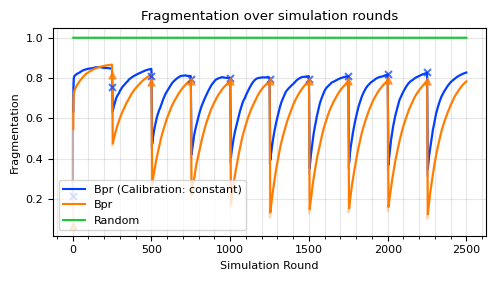

In [3]:
plot_metric_comparison(
    [bpr_calibrated, bpr_uncalibrated, random_rec],
    metric_name="frags",
    title="Fragmentation over simulation rounds",
    graph="line",
    plot_retrain_points=True,
    window_size=5,
    seed=42,
)

As expected, random recommendation achieves the higher fragmentation value as possible

Retrain reduces fragmentation, with each recommendation becomming more and more fragmented. This is mostly due to the fact that we don´t repeat recommendations, and each user model works differently. At each retrain, we reset this. Its  interesting to note that calibration fragments users faster than non calibrated variants. We don´t necessarily observe an effect of the feedback loop on fragmentation other than that retrain reduces fragmentation.

Moreover, the trend remains the same for both variants: as users interact with the system and we remove previously interacted items from the recommendations, users get more fragmented. However, calibration appears to have a magnitude shift, with a small shift towards a more fragmented environment.

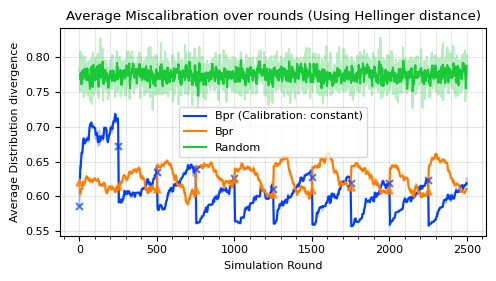

In [4]:
plot_metric_comparison(
    [bpr_calibrated, bpr_uncalibrated, random_rec],
    metric_name="diver",
    title="Average Miscalibration over rounds (Using Hellinger distance)",
    graph="line",
    plot_retrain_points=True,
    window_size=5,
    seed=42,
)

Interestingly, we see that retrain increases miscalibration for the uncalibrated version, while it decreases for the calibration version. This shows that, although calibration makes recommendations closely ressemble users initial taste, it makes recommendations more fragmented. Moreover, the effect of retraining is constracting between miscalibration and fragmentation: while retrain increases both miscalibration and fragmentation for uncalibrated versiosn, we observe a drop on miscalibration over time. 


At the same time, users tend to choose news more dissimilar than what they would choose after retraining the calibrated version, so that by the time model is retrained, both variants are usually equally miscalibrated. The same can be said aboud fragmentation.

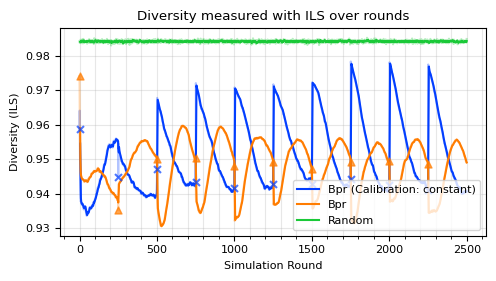

In [5]:
plot_metric_comparison(
    [bpr_calibrated, bpr_uncalibrated, random_rec],
    metric_name="div",
    title="Diversity measured with ILS over rounds",
    graph="line",
    plot_retrain_points=True,
    window_size=5,
    seed=42,
)

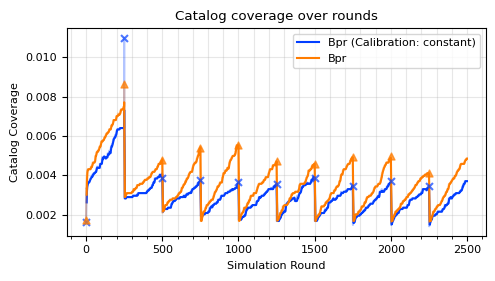

In [6]:
plot_metric_comparison(
    [bpr_calibrated, bpr_uncalibrated],
    metric_name="coverage",
    title="Catalog coverage over rounds",
    graph="line",
    plot_retrain_points=True,
    window_size=5,
    seed=42,
)

As expected, the catalog coverage for calibrated version is slightly smaller than uncalibrated version. 